In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt
import numpy as np
import pickle
from pathlib import Path

In [15]:
# Get the images and labels
train_imgs = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/train1c_imgs.npy')
train_labels = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/train1c_labels.npy')
train_meta = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/train1c_metadata.npy')
train_header_num = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/train1c_2h_num.npy')

val_imgs = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/val1c_imgs.npy')
val_labels = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/val1c_labels.npy')
val_meta = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/val1c_metadata.npy')
val_header_num = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/val1c_2h_num.npy')

test_imgs = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/test1c_imgs.npy')
test_labels = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/test1c_labels.npy')
test_meta = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/test1c_metadata.npy')
test_header_num = np.load('/hpcstor6/scratch01/a/anya.tongprasith001/U54REC/omama/split/test1c_2h_num.npy')

In [16]:
# Examine class label imbalance
neg, pos = np.bincount(train_labels.astype(int))
total = neg + pos
print('Examples:\n    Total: {}\n    Positive: {} ({:.2f}% of total)\n'.format(
    total, pos, 100 * pos / total))

Examples:
    Total: 10290
    Positive: 5145 (50.00% of total)



In [17]:
# Setup data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

In [18]:
# For numeric features
def get_normalization_layer(index, numeric):
    normalizer = layers.Normalization(axis=None)

    # one numeric column by index, keep shape (batch, 1)
    feature = np.asarray(numeric[:, index], dtype=np.float32).reshape(-1, 1)

    normalizer.adapt(feature)
    return normalizer

# For string categoray features
def get_category_encoding_layer(index, string, dtype, max_tokens=None):
  # Create a layer that turns strings into integer indices.
  if dtype == 'string':
    lookup = layers.StringLookup(max_tokens=max_tokens)
  # Otherwise, create a layer that turns integer values into integer indices.
  else:
    lookup = layers.IntegerLookup(max_tokens=max_tokens)

  # Prepare a `tf.data.Dataset` that only yields the feature.
  feature = np.asarray(string[:, index], dtype=str).reshape(-1, 1)

  # Learn the set of possible values and assign them a fixed integer index.
  lookup.adapt(feature)

  # Encode the integer indices.
  encoder = layers.CategoryEncoding(num_tokens=lookup.vocabulary_size())

  # Apply multi-hot encoding to the indices. The lambda function captures the
  # layer, so you can use them, or include them in the Keras Functional model later.
  return lambda feature: encoder(lookup(feature))

In [19]:
all_inputs = []
encoded_features = []

for i in range(train_header_num.shape[1]):
    input_col = tf.keras.Input(shape=(1,), dtype=tf.float32)  
    layer = get_normalization_layer(i, train_header_num)
    all_inputs.append(input_col)
    encoded_features.append(layer(input_col))

In [20]:
# Load in the images
def load_image(path, meta, label, header_num):
    def read_npz(p, m):
        p = p.decode() # From byte to string
        img = np.load(p)['data']

        window_min = m[0]
        window_max = m[1]
        img = np.clip(img, window_min, window_max)
        img = (img - window_min) / (window_max - window_min) * 255.0
        return img.astype(np.float32)
    
    img = tf.numpy_function(read_npz, [path, meta], tf.float32)
    img = tf.expand_dims(img, axis=-1)
    img.set_shape([1024, 1024, 1])
    num_features = [tf.expand_dims(header_num[i], axis=-1) for i in range(2)]
    
    return tuple([img] + num_features), label

In [21]:
# Create the dataset and group into batches
train_ds = tf.data.Dataset.from_tensor_slices((train_imgs, train_meta, train_labels, train_header_num))
train_ds = train_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1000)
train_ds = train_ds.batch(32)

val_ds = tf.data.Dataset.from_tensor_slices((val_imgs, val_meta, val_labels, val_header_num))
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(32)

test_ds = tf.data.Dataset.from_tensor_slices((test_imgs, test_meta, test_labels, test_header_num))
test_ds = test_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(32)

In [22]:
# Configure dataset performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [23]:
# Import pretrained model
base_model = tf.keras.applications.ResNet50(input_shape=(1024, 1024, 3),
                                                  include_top=False, # Don't include ImageNet classifier at the top,
                                                  weights='imagenet',
                                                 )
# Freeze base model
base_model.trainable = False

In [24]:
base_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 1024,      │          0 │ -                 │
│ (InputLayer)        │ 1024, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 1030,      │          0 │ input_layer_9[0]… │
│ (ZeroPadding2D)     │ 1030, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 512, 512,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 512, 512,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 512, 512,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 514, 514,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 256, 256,  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 256, 256,  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 256, 256,  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 256, 256,  │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 256, 256,  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 256, 256,  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 256, 256,  │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 256, 256,  │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 256, 256,  │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 256, 256,  │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 256, 256,  │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [25]:
# Image branch
# Convert image tensor from 1 channel to 3 for the model
image_input = tf.keras.Input(shape=(1024, 1024, 1), name = 'image_input')
x = data_augmentation(image_input)
x = tf.keras.layers.Concatenate()([x, x, x])
x = preprocess_input(x) 

# Keep base model in inference mode
x = base_model(x, training = False)
x = layers.GlobalAveragePooling2D()(x) # (batch, H, W, C) becomes (batch, C) — a single feature vector per image
x = layers.Dropout(0.2)(x)
x = layers.Dense(64, activation="relu")(x)

# Headers branch
header_features = layers.concatenate(encoded_features)
h = layers.Dense(32, activation="relu")(header_features)

combined = layers.concatenate([x, h])
outputs = layers.Dense(1, activation="sigmoid")(combined)   # add activation="sigmoid" # maps feature vectors to probability score 0-1
model = tf.keras.Model(inputs=[image_input] + all_inputs, outputs=outputs) # wrap all layers

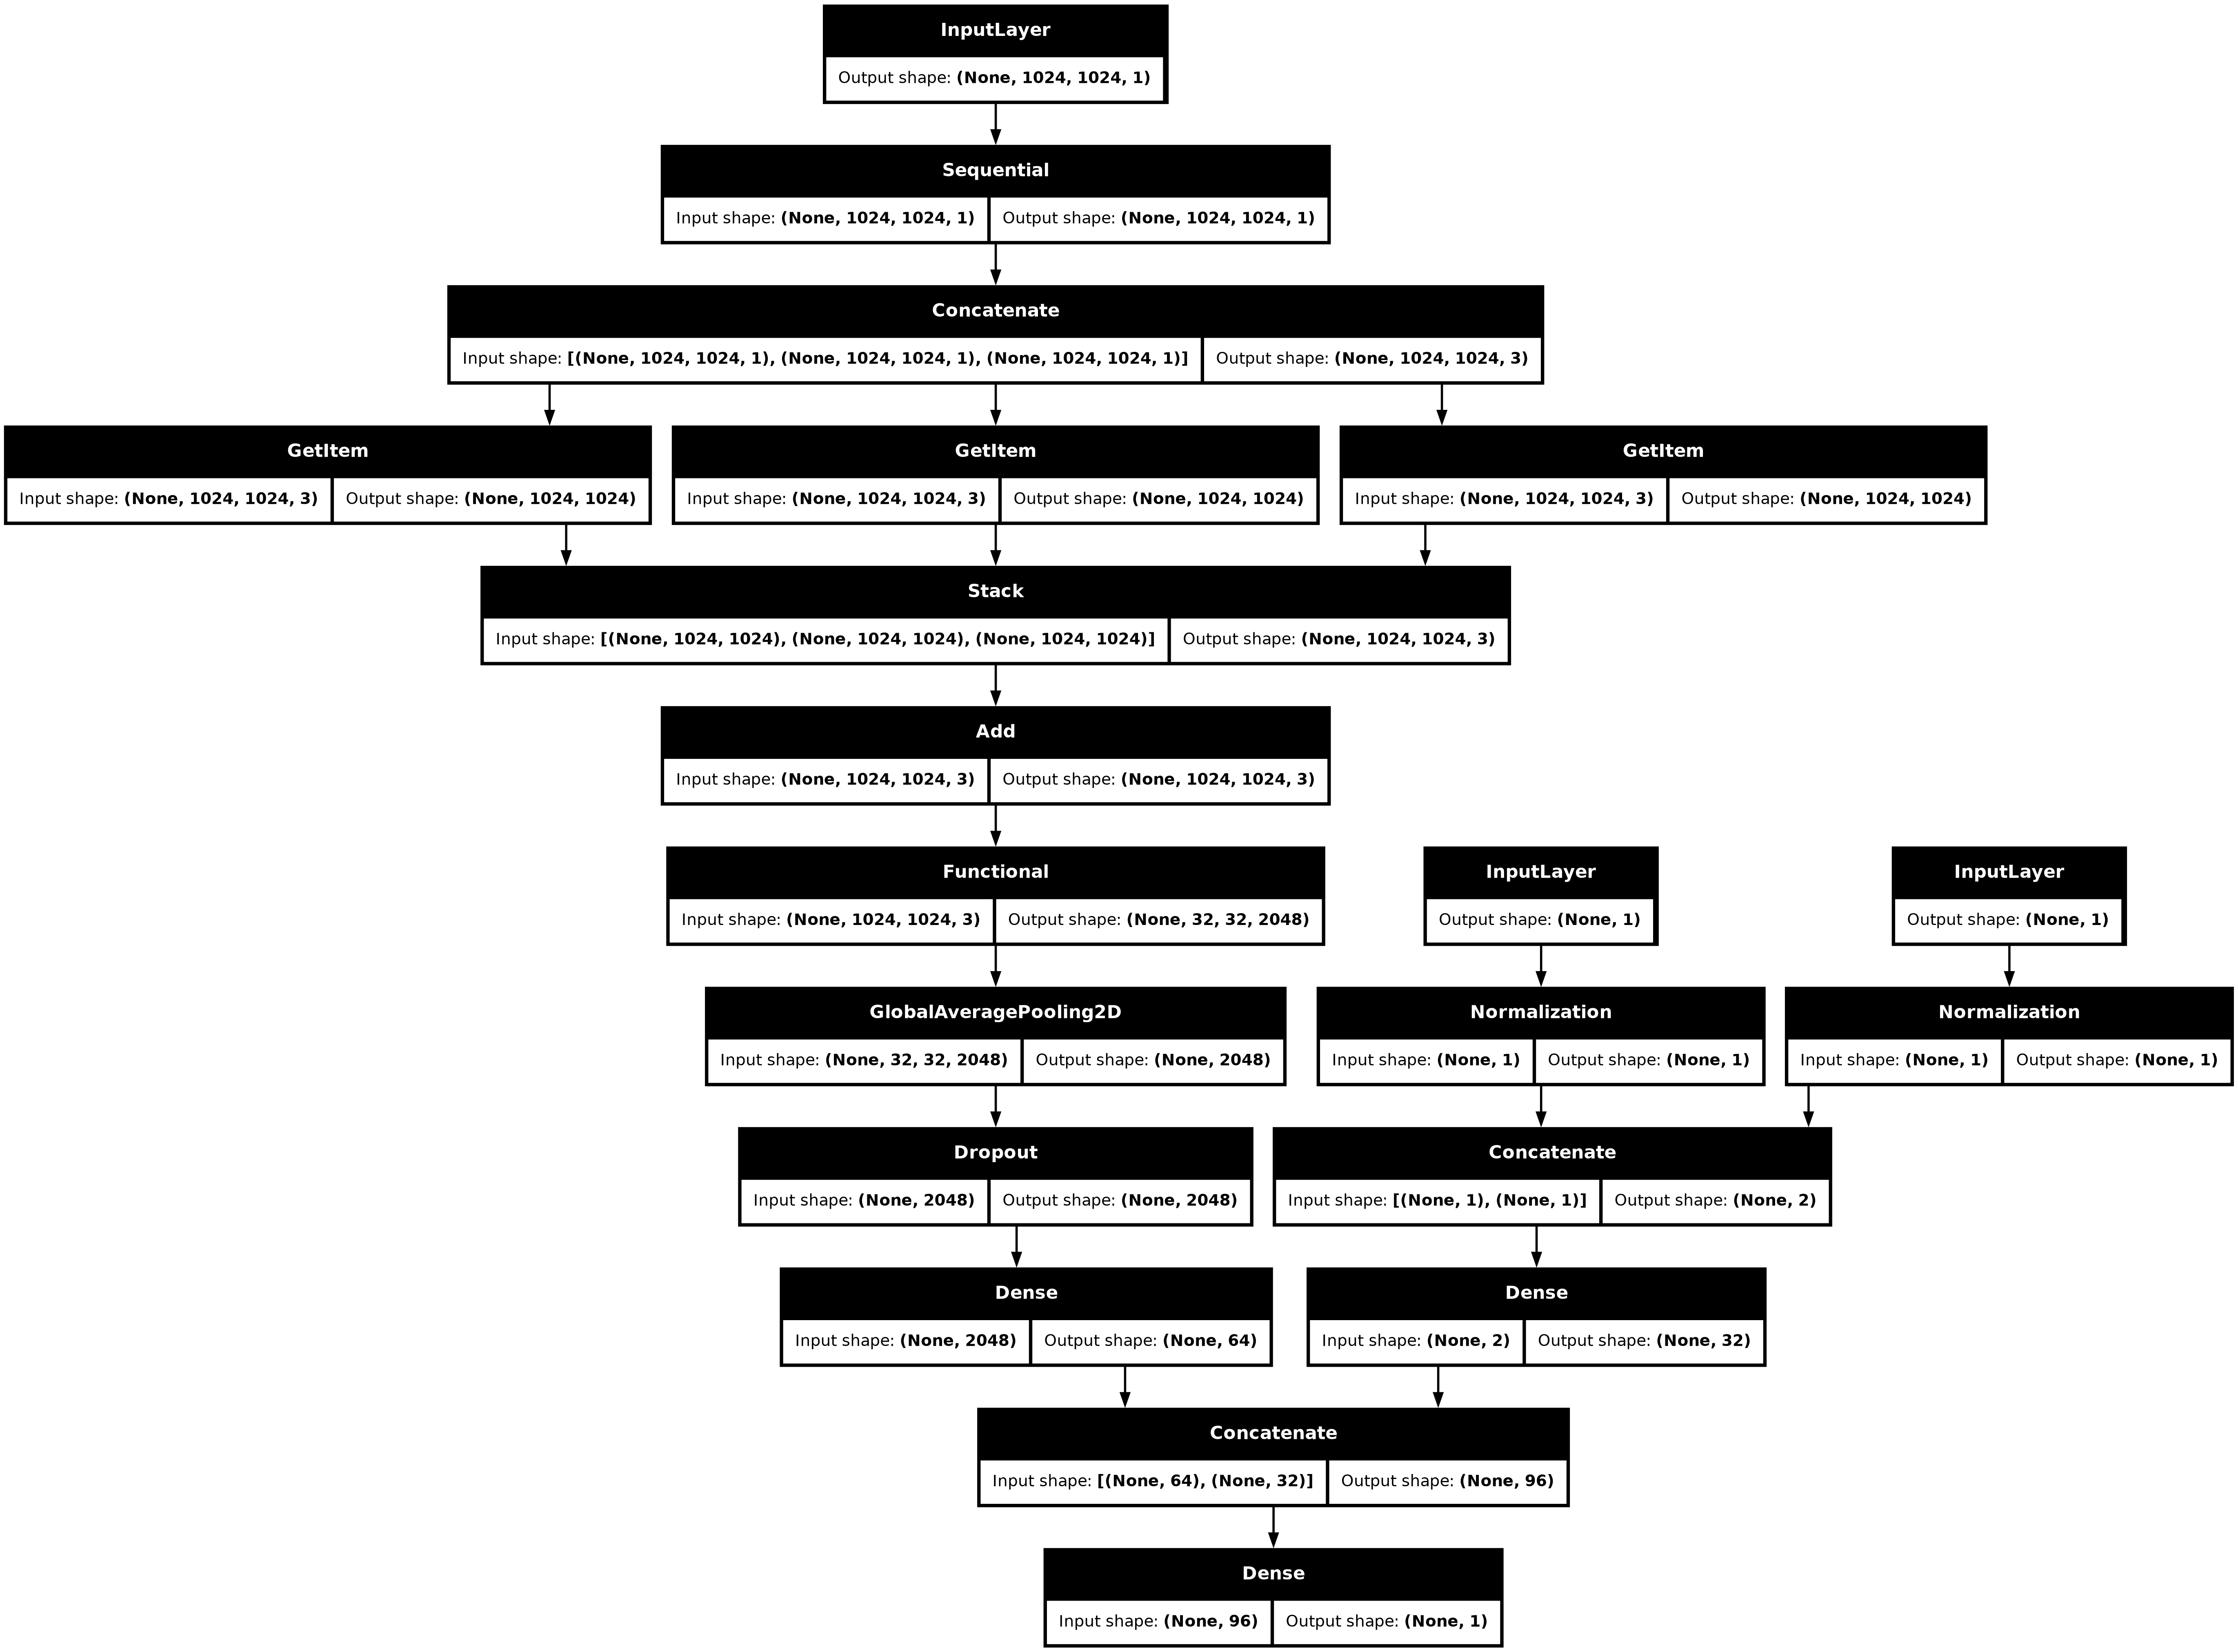

In [26]:
# Show input pipeline
tf.keras.utils.plot_model(model, "multi_input_and_output_model.png", show_shapes=True)

In [27]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 1024,      │          0 │ -                 │
│ (InputLayer)        │ 1024, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 1024,      │          0 │ image_input[0][0] │
│ (Sequential)        │ 1024, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 1024,      │          0 │ sequential_1[0][… │
│ (Concatenate)       │ 1024, 3)          │            │ sequential_1[0][… │
│                     │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 1024,      │          0 │ concatenate_3[0]… │
│ (GetItem)           │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 1024,      │          0 │ concatenate_3[0]… │
│ (GetItem)           │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 1024,      │          0 │ concatenate_3[0]… │
│ (GetItem)           │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 1024,      │          0 │ get_item_3[0][0], │
│                     │ 1024, 3)          │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1024,      │          0 │ stack_1[0][0]     │
│                     │ 1024, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 32, 32,    │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_8       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_5     │ (None, 1)         │          3 │ input_layer_7[0]… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_6     │ (None, 1)         │          3 │ input_layer_8[0]… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 2)         │          0 │ normalization_5[… │
│ (Concatenate)       │                   │            │ normalization_6[… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 23,719,047 (90.48 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 23,587,718 (89.98 MB)

In [28]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.AUC(curve="ROC", name = 'auc'),
    ]
)

In [29]:
# Early stopping callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=3,
        restore_best_weights=True,
        mode='max'
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_auc',
        save_best_only=True,
        mode='max'
    )
]

In [30]:
initial_epochs = 60
history = model.fit(train_ds, 
                    epochs=initial_epochs, 
                    validation_data = val_ds, 
                    callbacks = callbacks)

Epoch 1/60


I0000 00:00:1782934715.161058 2155363 cuda_dnn.cc:461] Loaded cuDNN version 92302
Could not load symbol cuFuncGetName. Error: /usr/lib/x86_64-linux-gnu/libcuda.so.1: undefined symbol: cuFuncGetName


322/322 ━━━━━━━━━━━━━━━━━━━━ 172s 469ms/step - auc: 0.5715 - loss: 0.6929 - val_auc: 0.6385 - val_loss: 0.6758
Epoch 2/60
322/322 ━━━━━━━━━━━━━━━━━━━━ 133s 392ms/step - auc: 0.6345 - loss: 0.6656 - val_auc: 0.6633 - val_loss: 0.6650
Epoch 3/60
322/322 ━━━━━━━━━━━━━━━━━━━━ 133s 392ms/step - auc: 0.6460 - loss: 0.6588 - val_auc: 0.6778 - val_loss: 0.6483
Epoch 4/60
322/322 ━━━━━━━━━━━━━━━━━━━━ 133s 392ms/step - auc: 0.6686 - loss: 0.6482 - val_auc: 0.6878 - val_loss: 0.6464
Epoch 5/60
322/322 ━━━━━━━━━━━━━━━━━━━━ 133s 392ms/step - auc: 0.6686 - loss: 0.6474 - val_auc: 0.6895 - val_loss: 0.6402
Epoch 6/60
322/322 ━━━━━━━━━━━━━━━━━━━━ 142s 392ms/step - auc: 0.6745 - loss: 0.6442 - val_auc: 0.6949 - val_loss: 0.6387
Epoch 7/60
322/322 ━━━━━━━━━━━━━━━━━━━━ 133s 392ms/step - auc: 0.6830 - loss: 0.6397 - val_auc: 0.6953 - val_loss: 0.6619
Epoch 8/60
322/322 ━━━━━━━━━━━━━━━━━━━━ 133s 392ms/step - auc: 0.6818 - loss: 0.6389 - val_auc: 0.6999 - val_loss: 0.6510
Epoch 9/60
322/322 ━━━━━━━━━━━━━━━━

In [31]:
# See how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

Number of layers in the base model:  175


In [32]:
base_model.trainable = True

# Fine-tune from this layer onwards
fine_tune_at = len(base_model.layers) - 50

# Unfreeze only the head layers
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

# Freeze BatchNorm layers
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

In [33]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 1024,      │          0 │ -                 │
│ (InputLayer)        │ 1024, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 1024,      │          0 │ image_input[0][0] │
│ (Sequential)        │ 1024, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 1024,      │          0 │ sequential_1[0][… │
│ (Concatenate)       │ 1024, 3)          │            │ sequential_1[0][… │
│                     │                   │            │ sequential_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 1024,      │          0 │ concatenate_3[0]… │
│ (GetItem)           │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 1024,      │          0 │ concatenate_3[0]… │
│ (GetItem)           │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 1024,      │          0 │ concatenate_3[0]… │
│ (GetItem)           │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 1024,      │          0 │ get_item_3[0][0], │
│                     │ 1024, 3)          │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1024,      │          0 │ stack_1[0][0]     │
│                     │ 1024, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 32, 32,    │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_8       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_5     │ (None, 1)         │          3 │ input_layer_7[0]… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization_6     │ (None, 1)         │          3 │ input_layer_8[0]… │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 2)         │          0 │ normalization_5[… │
│ (Concatenate)       │                   │            │ normalization_6[… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 23,981,707 (91.48 MB)

 Trainable params: 17,053,697 (65.05 MB)

 Non-trainable params: 6,665,350 (25.43 MB)

 Optimizer params: 262,660 (1.00 MB)

In [34]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=[
        tf.keras.metrics.AUC(curve="ROC", name = 'auc'),
    ],
)

In [35]:
# Train the model
fine_tune_epochs = 40
total_epochs =  initial_epochs + fine_tune_epochs
history_fine = model.fit(train_ds, 
                         epochs=total_epochs,       
                         initial_epoch=initial_epochs,  
                         validation_data=val_ds,
                         callbacks=callbacks)

Epoch 61/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 183s 492ms/step - auc: 0.7279 - loss: 0.6062 - val_auc: 0.7544 - val_loss: 0.5936
Epoch 62/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 157s 466ms/step - auc: 0.7678 - loss: 0.5688 - val_auc: 0.7645 - val_loss: 0.5913
Epoch 63/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 177s 527ms/step - auc: 0.7801 - loss: 0.5568 - val_auc: 0.7807 - val_loss: 0.5751
Epoch 64/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 156s 463ms/step - auc: 0.7974 - loss: 0.5381 - val_auc: 0.7778 - val_loss: 0.5533
Epoch 65/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 202s 463ms/step - auc: 0.8074 - loss: 0.5254 - val_auc: 0.7720 - val_loss: 0.5707
Epoch 66/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 203s 466ms/step - auc: 0.8193 - loss: 0.5096 - val_auc: 0.7933 - val_loss: 0.5458
Epoch 67/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 157s 466ms/step - auc: 0.8237 - loss: 0.5060 - val_auc: 0.7946 - val_loss: 0.5687
Epoch 68/100
322/322 ━━━━━━━━━━━━━━━━━━━━ 157s 467ms/step - auc: 0.8355 - loss: 0.4917 - val_auc: 0.7956 - val_loss: 0.5643
Epoch 69

In [36]:
# Evaluate model
model.evaluate(test_ds)

69/69 ━━━━━━━━━━━━━━━━━━━━ 22s 309ms/step - auc: 0.8140 - loss: 0.5811


[0.5811410546302795, 0.8140177726745605]

In [37]:
from sklearn.metrics import confusion_matrix

# Analyse confusion matrix
y_prob = model.predict(test_ds).reshape(-1)
y_pred = (y_prob >= 0.5).astype(int)
y_true = test_labels.astype(int)

cm = confusion_matrix(y_true, y_pred)

69/69 ━━━━━━━━━━━━━━━━━━━━ 25s 331ms/step


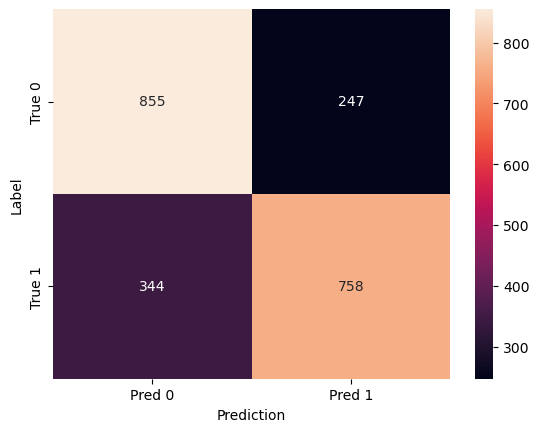

In [38]:
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'])
plt.xlabel('Prediction')
plt.ylabel('Label')
plt.show()

In [39]:
from sklearn.metrics import f1_score
f1 = f1_score(y_true, y_pred)
print(f"F1 Score: {f1:.4f}")

F1 Score: 0.7195


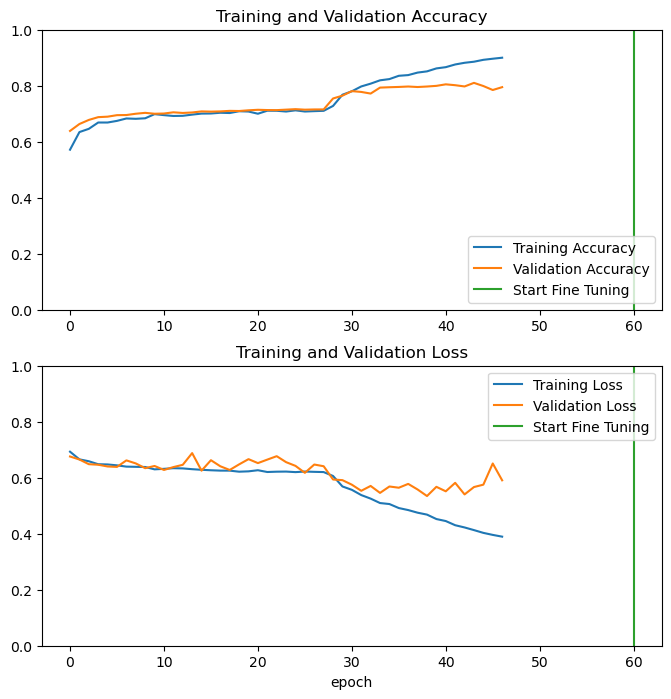

In [40]:
# Combine both for plotting
acc = history.history['auc'] + history_fine.history['auc']
val_acc = history.history['val_auc'] + history_fine.history['val_auc']
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

# Plot
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0, 1.0])
plt.plot([initial_epochs,initial_epochs],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([initial_epochs,initial_epochs],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

In [ ]:
print(history.history.keys())
print(history_fine.history.keys())